# 23 — Variable-cell relaxation

`calculation = 'vc-relax'` relaxes the **cell** as well as the atoms. The cell is nine
more coordinates in the same BFGS, its gradient is the stress rearranged,

    dH/dh = Omega (P I - sigma) h^-T,     H = E + P Omega,

and the two things that fall out of that expression are the whole of the physics: what is
minimised is the **enthalpy**, and the stationary point is `sigma = P I` — a relaxed
crystal carries the applied pressure rather than having no stress.

The case below is QE's own `pw_vc-relax/vc-relax4.in`: rhombohedral arsenic squeezed at
**500 kbar**, where the cell compresses by 10% *and* the two atoms move from 0.2722 to
0.2500 — the rhombohedral-to-simple-cubic transition. Against `pw.x` the relaxed volume
agrees to **7e-4 bohr³**, the atoms to **2.4e-6** in crystal coordinates and the final
energy to **2.4e-6 Ry**, in the same ten ionic steps.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso.io import read_qe_output
from pypresso.io.pwin import read_pw_input
from pypresso.pseudo import read_upf
from pypresso.system import build_system
from pypresso.units import RY_TO_KBAR
from pypresso.workflows.vc_relax import run_vc_relax

CASES = Path("../tests/data/qe")
PSEUDO = Path("../tests/data/pseudo")
QE = Path("../quantum_espresso/qe-7.5-ReleasePack/qe-7.5/test-suite/pw_vc-relax")

system = build_system(read_pw_input(QE / "vc-relax4.in"))
pseudos = tuple(read_upf(PSEUDO / s.pseudo_file) for s in system.structure.species)
print(f"{system.structure.nat} atoms, applied pressure {system.relax.press} kbar, "
      f"starting volume {float(system.cell.volume):.2f} bohr^3")

2 atoms, applied pressure 500.0 kbar, starting volume 245.37 bohr^3


## Run it

Everything the run needs is in the input: `press`, `press_conv_thr` and `cell_dofree` come
off the `&cell` namelist, and all three convergence thresholds — energy, force **and**
pressure — have to be satisfied together.

In [2]:
result = run_vc_relax(system, pseudos, conv_thr=1e-10)

print(f"converged in {result.nsteps} ionic steps")
print(f"volume   {result.steps[0].volume:8.2f}  ->  {result.volume:8.2f} bohr^3")
print(f"energy   {result.total_energy:.8f} Ry")
print(f"enthalpy {result.enthalpy:.8f} Ry")
print(f"pressure {np.trace(result.stress) / 3 * RY_TO_KBAR:.2f} kbar "
      f"(asked for {system.relax.press})")

converged in 10 ionic steps
volume     245.37  ->    190.79 bohr^3
energy   -25.39781626 Ry
enthalpy -24.74934425 Ry
pressure 502.04 kbar (asked for 500.0)


## Against `pw.x`

What is compared is the relaxed geometry and the energy of the **final SCF** — the extra
run QE does at the relaxed cell with the G-vectors recalculated for it. The relaxation
itself runs in a basis chosen for the *starting* cell (`scale_h.f90` re-expresses the same
Miller indices against the new reciprocal cell and changes nothing else), so its own last
energy is not variational in the cell it is reported at. The gap between the two is the
Pulay error of the frozen basis, and it is the number to read before believing a relaxed
volume from a low cutoff.

In [3]:
reference = read_qe_output(CASES / "reference.out.pw_vc-relax-vc-relax4")
qe_crystal = reference.final_positions @ np.linalg.inv(reference.final_cell)

rows = [
    ("volume (bohr^3)", result.volume, abs(np.linalg.det(reference.final_cell))),
    ("a1 . x (bohr)", result.cell[0, 0], reference.final_cell[0, 0]),
    ("a1 . z (bohr)", result.cell[0, 2], reference.final_cell[0, 2]),
    ("As at (crystal)", result.positions_crystal[0, 0], qe_crystal[0, 0]),
    # ``final_total_energy``: the *last* "!  total energy" in the file, which is
    # the final SCF's. ``total_energy`` is the first -- the starting geometry's.
    ("total energy (Ry)", result.total_energy, reference.final_total_energy),
]
print(f"{'':20s} {'pypresso':>14s} {'pw.x':>14s} {'difference':>12s}")
for label, ours, theirs in rows:
    print(f"{label:20s} {ours:14.6f} {theirs:14.6f} {abs(ours - theirs):12.2e}")
print(f"\nPulay error of the frozen basis: {result.pulay_error:.2e} Ry")

                           pypresso           pw.x   difference
volume (bohr^3)          190.787050     190.787743     6.93e-04
a1 . x (bohr)              3.744124       3.744159     3.50e-05
a1 . z (bohr)              5.238375       5.238296     7.88e-05
As at (crystal)            0.250001       0.250004     2.35e-06
total energy (Ry)        -25.397816     -25.397819     2.36e-06

Pulay error of the frozen basis: 3.67e-03 Ry


## The physics: the cell and the atoms are doing different things

Arsenic's rhombohedral structure is a distorted simple cubic one — the two atoms sit at
`±u(1,1,1)` with `u = 0.2722` instead of the `0.25` that would make every bond equal.
Pressure removes the distortion. The plot is that transition happening: the volume falls
and `u` climbs to a quarter, and neither is imposed.

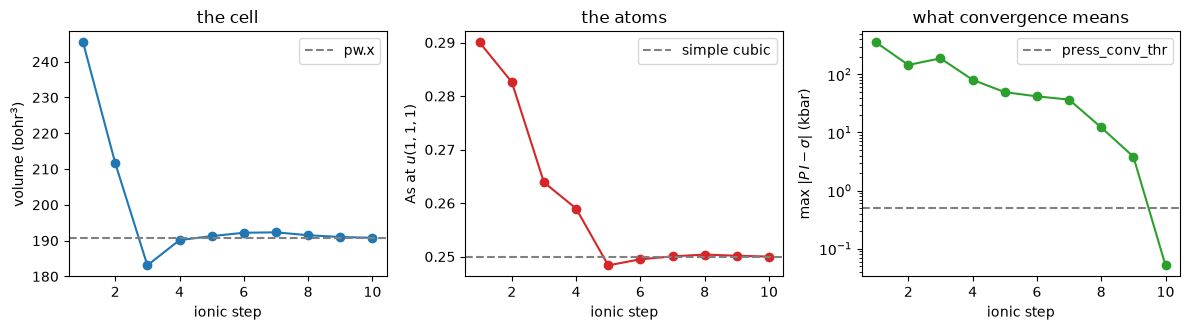

In [4]:
steps = result.steps
volume = [s.volume for s in steps]
u = [s.positions[0] @ np.linalg.inv(s.cell) for s in steps]
u = [x[0] for x in u]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))

axes[0].plot(range(1, len(steps) + 1), volume, "o-", color="#1f77b4")
axes[0].axhline(abs(np.linalg.det(reference.final_cell)), ls="--", color="grey",
                label="pw.x")
axes[0].set_xlabel("ionic step"); axes[0].set_ylabel("volume (bohr$^3$)")
axes[0].set_title("the cell"); axes[0].legend()

axes[1].plot(range(1, len(steps) + 1), u, "o-", color="#d62728")
axes[1].axhline(0.25, ls="--", color="grey", label="simple cubic")
axes[1].set_xlabel("ionic step"); axes[1].set_ylabel("As at $u(1,1,1)$")
axes[1].set_title("the atoms"); axes[1].legend()

axes[2].plot(range(1, len(steps) + 1),
             [s.cell_error * RY_TO_KBAR for s in steps], "o-", color="#2ca02c")
axes[2].axhline(system.relax.press_conv_thr, ls="--", color="grey",
                label="press_conv_thr")
axes[2].set_yscale("log")
axes[2].set_xlabel("ionic step"); axes[2].set_ylabel(r"max $|P\,I - \sigma|$ (kbar)")
axes[2].set_title("what convergence means"); axes[2].legend()

fig.tight_layout()

## How it works: the cell gradient is the stress, rearranged

Write the cell as `h`, the matrix whose *columns* are the lattice vectors. A deformation
`h -> (1 + eps) h` gives `eps = dh h^-1`, so `dE/dh = (dE/d eps) h^-T`; with
`sigma = -(1/Omega) dE/d eps` and `d Omega/dh = Omega h^-T`, the enthalpy's gradient is
`Omega (P I - sigma) h^-T`. That is `cell_base.f90`'s `cell_force`, and contracting it
back with `h^T` returns `P I - sigma`, which is why the cell's convergence is reported in
kbar. Nothing new is differentiated: the stress it is built from is P11's single
`jax.grad` of the energy along a strain.

In [5]:
from pypresso.relax.cell import cell_force

h = result.cell.T                      # QE's convention: lattice vectors as columns
omega = result.volume
pressure = system.relax.press / RY_TO_KBAR

gradient = cell_force(result.stress, h, omega, pressure)
recovered = gradient @ h.T / omega     # ... must be P I - sigma again

print("dH/dh at the relaxed cell (Ry/bohr):")
print(np.array2string(gradient, precision=6, suppress_small=True))
print("\ncontracted back, max |P I - sigma| =",
      f"{np.abs(recovered).max() * RY_TO_KBAR:.3f} kbar")

dH/dh at the relaxed cell (Ry/bohr):
[[-0.000443  0.000221  0.000221]
 [-0.       -0.000384  0.000384]
 [-0.000187 -0.000187 -0.000187]]

contracted back, max |P I - sigma| = 2.271 kbar


## The trap: a moving cell makes stale k-points reachable

`KPoints.coords` are cartesian in units of `2 pi / alat`, so they describe a k-set only
together with the cell they were built for. What is fixed under a deformation is `k` in
**crystal** coordinates. Every caller before this phase deformed a cell whose k-points had
just been built for it, where the distinction cannot be seen; a cell that has actually
*moved* separates them, and a stress taken there was differentiated at k-points 0.031 away
in crystal units from the ones the SCF had run at — the energy right, its derivative wrong
by 64 kbar and the relaxed volume by 2%. A finite difference of the frozen-basis energy is
what settled it, and it is the check below.

In [6]:
print(f"{'crystal k-point':>28s}   {'from the run':>22s}")
base = np.asarray(system.kpoints.crystal(system.cell))
final = np.asarray(result.system.kpoints.crystal(result.system.cell))
for a, b in list(zip(base, final))[:3]:
    print(f"{np.array2string(a, precision=5):>28s}   {np.array2string(b, precision=5):>22s}")
print(f"\nmax difference after the cell moved: {np.abs(base - final).max():.2e}")

             crystal k-point             from the run
         [0.125 0.125 0.125]      [0.125 0.125 0.125]
         [0.125 0.125 0.375]      [0.125 0.125 0.375]
      [ 0.125  0.125 -0.375]   [ 0.125  0.125 -0.375]

max difference after the cell moved: 1.11e-16


---

The phase entry is `PLAN.md` §3, **P29** — including the two bugs this case found (the
stale k-points above, and a symmetry tolerance that was absolute in bohr where QE's is in
units of `alat`). The tests are `tests/regression/test_vc_relax.py`: QE's three comparable
`pw_vc-relax` cases plus an eight-atom cubic silicon supercell under pressure and the
ten-atom graphite whose `c` and `a` have to move independently.